# Guia: NaN en batch y padding solo antes del backbone


## 1. Imports

In [34]:
from pathlib import Path 
import os
import sys
import math

import torch as tr
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [35]:
import torch as tr
import torch.nn.functional as F

def x_to_one_hot(x, num_classes):
    if x.dim() == 4:
        return x.float()
    return F.one_hot(x, num_classes=num_classes).permute(0, 3, 1, 2).float()

def sample_categorical(logits, mask=None):
    uniform = tr.rand_like(logits)
    gumbel_noise = -tr.log(-tr.log(uniform + 1e-30) + 1e-30)
    sampled = (gumbel_noise + logits).argmax(dim=1)   # [B, H, W]

    if mask is None:
        return sampled

    if mask.ndim == 4:
        mask = mask.squeeze(1)
    mask = mask.bool()

    out = tr.zeros_like(sampled)
    out[mask] = sampled[mask]
    return out

def sample_from_probs_gumbel(probs, mask=None):
    # probs: [B, C, H, W]
    probs = tr.clamp(probs, min=1e-30)
    probs = probs / (probs.sum(dim=1, keepdim=True) + 1e-8)
    logits = tr.log(probs)
    return sample_categorical(logits, mask=mask)   # devuelve indices [B,H,W]

def sample_from_probs_multinomial(probs, mask=None):
    # probs: [B, C, H, W]
    probs = tr.clamp(probs.permute(0, 2, 3, 1), min=1e-30)  # [B,H,W,C]
    probs = probs / (probs.sum(dim=-1, keepdim=True) + 1e-8)

    if mask is not None:
        valid = mask.squeeze(1).bool()
        sampled = tr.zeros(probs.shape[:3], device=probs.device, dtype=tr.long)
        sampled[valid] = tr.multinomial(probs[valid], 1).squeeze(-1)
        return sampled

    return tr.multinomial(
        probs.reshape(-1, probs.shape[-1]), 1
    ).squeeze(-1).reshape(probs.shape[:3])


In [ ]:
# -----------------------------
# tensor de juguete
# -----------------------------
# B=1, C=3, H=2, W=2
probs = tr.tensor([
    [
        [[0.7, 0.1],
         [0.2, 0.5]],   # clase 0

        [[0.2, 0.8],
         [0.3, 0.2]],   # clase 1

        [[0.1, 0.1],
         [0.5, 0.3]],   # clase 2
    ]
], dtype=tr.float)

# mascara opcional
mask = tr.tensor([[[[1, 1],
                    [0, 1]]]], dtype=tr.bool)

print("probs shape:", probs.shape)   # [1,3,2,2]
print("mask shape:", mask.shape)     # [1,1,2,2]

# -----------------------------
# muestrear 30 veces
# -----------------------------
n = 200
samples_gumbel = []
samples_mult = []

tr.manual_seed(0)
for _ in range(n):
    samples_gumbel.append(sample_from_probs_gumbel(probs, mask=mask))

tr.manual_seed(0)
for _ in range(n):
    samples_mult.append(sample_from_probs_multinomial(probs, mask=mask))

samples_gumbel = tr.stack(samples_gumbel)   # [30,B,H,W]
samples_mult   = tr.stack(samples_mult)     # [30,B,H,W]

print("\nPrimeras 5 muestras Gumbel:")
print(samples_gumbel[:5, 0])

print("\nPrimeras 5 muestras Multinomial:")
print(samples_mult[:5, 0])

probs shape: torch.Size([1, 3, 2, 2])
mask shape: torch.Size([1, 1, 2, 2])

Primeras 5 muestras Gumbel:
tensor([[[0, 1],
         [0, 1]],

        [[1, 1],
         [0, 2]],

        [[0, 1],
         [0, 1]],

        [[0, 0],
         [0, 0]],

        [[1, 1],
         [0, 0]]])

Primeras 5 muestras Multinomial:
tensor([[[2, 1],
         [0, 0]],

        [[0, 0],
         [0, 2]],

        [[0, 1],
         [0, 0]],

        [[0, 0],
         [0, 1]],

        [[1, 1],
         [0, 1]]])


In [ ]:
# -----------------------------
# comparar frecuencias empiricas
# -----------------------------
num_classes = probs.shape[1]

def empirical_freq(samples, num_classes):
    # samples: [N,B,H,W]
    N, B, H, W = samples.shape
    out = tr.zeros(B, num_classes, H, W)
    for c in range(num_classes):
        out[:, c] = (samples == c).float().mean(dim=0)
    return out

freq_gumbel = empirical_freq(samples_gumbel, num_classes)
freq_mult   = empirical_freq(samples_mult, num_classes)

print("\nFrecuencias empíricas Gumbel:")
print(freq_gumbel[0])

print("\nFrecuencias empíricas Multinomial:")
print(freq_mult[0])

print("\nProbabilidades originales:")
print(probs[0])


Frecuencias empíricas Gumbel:
tensor([[[0.7200, 0.1450],
         [1.0000, 0.5450]],

        [[0.1950, 0.7400],
         [0.0000, 0.2000]],

        [[0.0850, 0.1150],
         [0.0000, 0.2550]]])

Frecuencias empíricas Multinomial:
tensor([[[0.7150, 0.1200],
         [1.0000, 0.5300]],

        [[0.1700, 0.7950],
         [0.0000, 0.2150]],

        [[0.1150, 0.0850],
         [0.0000, 0.2550]]])

Probabilidades originales:
tensor([[[0.7000, 0.1000],
         [0.2000, 0.5000]],

        [[0.2000, 0.8000],
         [0.3000, 0.2000]],

        [[0.1000, 0.1000],
         [0.5000, 0.3000]]])


In [ ]:
def x_to_one_hot(x, num_classes):
    if x.dim() == 4:
        return x.float()
    else:
        # x is [B, H, W], convert to one-hot [B, C, H, W]
        return F.one_hot(x, num_classes=num_classes).permute(0, 3, 1, 2).float()
    
def gumbel_sample(logits):
    uniform = tr.rand_like(logits)
    gumbel_noise = -tr.log(-tr.log(uniform + 1e-30) + 1e-30)
    return (gumbel_noise + logits).argmax(dim=1)
    
def sample_categorical(logits, mask=None):
    if mask is None:
        return gumbel_sample(logits)
    else:
        if mask.ndim == 4:
            mask = mask.squeeze(1) # [B, L, L]
        valid_logits = logits.permute(0, 2, 3, 1)[mask]
    sampled = gumbel_sample(valid_logits)
    out = tr.full_like(logits.squeeze(1), fill_value=float("nan"))
    out[mask] = sampled
    return out # [B, H, W]

def sample_from_probs(probs, mask=None):
    # probs: [B, C, H, W] 
    probs = tr.clamp(probs, min=1e-30)
    probs = probs / (probs.sum(dim=1, keepdim=True) + 1e-8)
    logits = tr.log(probs)
    return sample_categorical(logits, mask=mask)


def x_to_one_hot(self, x, mask=None, keep_nan=True): 
    if x.dim() == 4:
        x_oh = x.float()
        if mask is None:
            return x_oh
        if mask.ndim == 4:
            mask = mask.squeeze(1)
        mask = mask.bool()
        valid = mask.unsqueeze(1).expand_as(x_oh)
        fill = float("nan") if keep_nan else 0.0
        out = tr.full_like(x_oh, fill)
        out[valid] = x_oh[valid]
        return out

    if mask is None:
        mask = ~tr.isnan(x)
    elif mask.ndim == 4:
        mask = mask.squeeze(1) # [B,H,W]

    B, H, W = x.shape
    C = self.num_classes
 
    out = tr.full((B, C, H, W), float("nan"), device=x.device, dtype=tr.float32)

    x_safe = tr.nan_to_num(x, nan=0.0).long()
    x_valid = x_safe[mask]                                 # [N_valid]
    oh_valid = F.one_hot(x_valid, num_classes=C).float()   # [N_valid, C]

    out_hwc = out.permute(0, 2, 3, 1)           # [B,H,W,C]
    out_hwc[mask] = oh_valid
    out = out_hwc.permute(0, 3, 1, 2)           # [B,C,H,W]

    return out

In [39]:
def repo_root():
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / 'src').exists() and (p / 'data').exists():
            return p.resolve()
    raise RuntimeError('Run this notebook from inside the repo.')

ROOT = repo_root()
os.chdir(ROOT)
sys.path.insert(0, str(ROOT)) 

# collate_fn

In [40]:
"""Collate functions for DataLoaders."""

def pad_batch(batch):
    """Batch is a dictionary with different variable lists."""

    L = [b["length"] for b in batch]
    raw_max_len = max(L)
    # Ceil max length to a multiple of 4 to keep downsampling valid.
    max_len = math.ceil(raw_max_len / 4) * 4 
    embedding_pad = tr.full((len(batch), batch[0]["embedding"].shape[0], max_len), float('nan')) 
    conditioning_padded = tr.full((len(batch), batch[0]["conditioning"].shape[0], max_len, max_len), float('nan'))# mask (B, 1, L, L)
    mask_pad = tr.zeros((len(batch), 1, max_len, max_len), dtype=tr.bool)

    if batch[0]["contact"] is None:
        contact_pad = None
        contact_oh_pad = None
    else: 
        # make nan padding
        contact_pad = tr.full((len(batch), max_len, max_len), float('nan'))
        contact_oh_pad = tr.full((len(batch), 2, max_len, max_len), float('nan'))

    for k in range(len(batch)):
        embedding_pad[k, :, : L[k]] = batch[k]["embedding"]
        conditioning_padded[k, :, : L[k], : L[k]] = batch[k]["conditioning"]

        mask_pad[k, :, :L[k], :L[k]] = True
        if contact_pad is not None:
            contact_pad[k, : L[k], : L[k]] = batch[k]["contact"]
            contact_oh_pad[k, :, : L[k], : L[k]] = batch[k]["contact_oh"]

    out_batch = {"id": [b["id"] for b in batch],
                 "sequence": [b["sequence"] for b in batch],
                 "length": L,
                 "embedding": embedding_pad,
                 "conditioning": conditioning_padded,
                 "contact": contact_pad,
                 "contact_oh": contact_oh_pad,
                 "mask": mask_pad}

    return out_batch


# Model

In [59]:


def linear_betas(timesteps):
    betas = tr.linspace(0.0001, 0.01, timesteps, dtype=tr.float32)
    return betas

def cosine_betas(timesteps, s=0.02):
    """
    Cosine schedule as proposed in https://arxiv.org/abs/2102.09672
    Better for discrete data to prevent abrupt noise injection.
    """
    steps = timesteps + 1
    x = tr.linspace(0, timesteps, steps, dtype=tr.float32)
    alphas_cumprod = tr.cos(((x / timesteps) + s) / (1 + s) * math.pi * 0.5) ** 2
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
    betas = tr.clip(betas, 0, 0.999)
    betas[0] = 1e-7
    return betas

def get_schedule(timesteps, get_betas, log=False):
    # beta = 1 - alpha
    betas = get_betas(timesteps)
    alphas = 1 - betas
    alphas_bar = tr.cumprod(alphas, dim=0)
    one_minus_alphas_bar = 1 - alphas_bar
    if log:
        return tr.log(betas), tr.log(alphas) , tr.log(alphas_bar), tr.log(one_minus_alphas_bar)
    else:
        return betas, alphas, alphas_bar, one_minus_alphas_bar

def extract(a, t, x_shape):
    """Extract values from `a` at indices `t` and reshape to match `x_shape`."""
    batch_size = t.shape[0]
    out = a.gather(-1, t)  # Extract values at indices `t`
    return out.reshape(batch_size, *((1,) * (len(x_shape) - 1)))  # Reshape to match `x_shape`

# ref https://github.com/ehoogeboom/multinomial_diffusion/blob/main/diffusion_utils/diffusion_multinomial.py
# ref 2 https://github.com/lucidrains/denoising-diffusion-pytorch/blob/5989f4c77eafcdc6be0fb4739f0f277a6dd7f7d8/denoising_diffusion_pytorch/denoising_diffusion_pytorch.py

class DiffusionModel(nn.Module):
    def __init__(self, num_classes, time_steps, model, schedule="cosine", **kwargs):
        super().__init__()
        self.diffuser = model(**kwargs)
        self.num_classes = num_classes
        self.time_steps = time_steps

        # about buffers: https://discuss.pytorch.org/t/what-is-the-difference-between-register-buffer-and-register-parameter-of-nn-module/32723
        # Register buffers with shape (T, 1, 1, 1).
        # This enables direct broadcasting over [B, C, H, W] without .view().
        if schedule == "linear":
            beta_fn = linear_betas
        else:
            beta_fn = cosine_betas
        betas, alphas, alphas_bar, one_minus_alphas_bar = get_schedule(time_steps, beta_fn)
        self.register_buffer("one_minus_alphas", 1 - alphas)
        self.register_buffer("alphas", alphas)
        self.register_buffer("alphas_bar", alphas_bar)
        self.register_buffer("one_minus_alphas_bar", one_minus_alphas_bar)

        # Optional buffer for stochastic NLL (if needed).
    def x_to_one_hot(self, x, mask=None):
        # Caso ya one-hot
        if x.dim() == 4:
            x = x.float()
            if mask is None:
                return x
            if mask.ndim == 3:
                mask = mask.unsqueeze(1) 
                
            out = tr.full_like(x, float("nan"))
            out[mask] = x[mask]
            return out

        # Caso índices [B,H,W] con NaNs posibles
        if mask is None:
            mask = ~tr.isnan(x)
        elif mask.ndim == 4:
            mask = mask.squeeze(1)

        x_safe = tr.nan_to_num(x, nan=0.0).long()
        x_oh = F.one_hot(x_safe, num_classes=self.num_classes).permute(0, 3, 1, 2).float()

        out = tr.full_like(x_oh, float("nan"))
        out[mask] = x_oh[mask]
        return out
    # def x_to_one_hot(self, x):
    #     if x.dim() == 4:
    #         return x.float()
    #     else:
    #         # x is [B, H, W], convert to one-hot [B, C, H, W]
    #         return F.one_hot(x.long(), num_classes=self.num_classes).permute(0, 3, 1, 2).float()

    def _prepare_backbone_inputs(self, xt_input, condition, mask=None):
        xt_input = self.x_to_one_hot(xt_input)
        if mask is None:
            return xt_input, condition

        xt_fill = tr.zeros_like(xt_input)
        print(xt_fill.shape)
        xt_fill[:, 0, :, :] = 1.0
        valid_xt = mask.expand_as(xt_input)
        valid_cond = mask.expand_as(condition)

        xt_backbone = tr.where(valid_xt, xt_input, xt_fill)
        cond_backbone = tr.where(valid_cond, condition, tr.zeros_like(condition))
        return xt_backbone, cond_backbone
        
    def sample_categorical(self, logits, mask=None):
        # logits: [B, C, H, W]
        uniform = tr.rand_like(logits)
        gumbel_noise = -tr.log(-tr.log(uniform + 1e-30) + 1e-30)
        sampled_all = (gumbel_noise + logits).argmax(dim=1).float()  # [B,H,W]

        if mask is None:
            return sampled_all

        if mask.ndim == 4:
            mask = mask.squeeze(1)
        mask = mask.bool()

        out = tr.full_like(sampled_all, float("nan"))
        out[mask] = sampled_all[mask]
        return out

    def sample_from_probs(self, probs, mask=None):
        # probs: [B, C, H, W]
        probs = tr.clamp(probs, min=1e-30)
        probs = probs / (probs.sum(dim=1, keepdim=True) + 1e-8)
        logits = tr.log(probs)
        sample = self.sample_categorical(logits, mask=mask)
        return sample

    def q_pred(self, x0, t):
        """Given x0 and time t, compute q(xt|x0)."""
        
        x0_one_hot = self.x_to_one_hot(x0)
        alphas_bar = extract(self.alphas_bar, t, x0_one_hot.shape)
        one_minus_alphas_bar = extract(self.one_minus_alphas_bar, t, x0_one_hot.shape)
        probs = alphas_bar * x0_one_hot + one_minus_alphas_bar / self.num_classes
        return probs # [B, C, H, W]

    def q_step(self, xt_1, t):
        """Given xt_1 and time t, compute q(xt|xt_1)."""
        xt_1_one_hot = self.x_to_one_hot(xt_1)
 
        alphas_t = extract(self.alphas, t, xt_1_one_hot.shape)
        one_minus_alpha_t = extract(self.one_minus_alphas, t, xt_1_one_hot.shape)
        qxt = alphas_t * xt_1_one_hot + one_minus_alpha_t / self.num_classes
        return qxt # [B, C, H, W]

    def q_posterior(self, x0, xt, t):
        """Given xt, x0 and time t, compute q(xt-1|xt,x0).""" 
        
        x0_one_hot = self.x_to_one_hot(x0)
        t_1 = tr.clamp(t - 1, min=0)
        qxt_1_given_x0 = self.q_pred(x0_one_hot, t_1)
        qxt_1_given_x0 = tr.where(
            t.view(-1, 1, 1, 1) == 0,
            x0_one_hot,
            qxt_1_given_x0,
        )
        qxt_given_xt_1 = self.q_step(xt, t)
        posterior = qxt_1_given_x0 * qxt_given_xt_1
        posterior = posterior / (posterior.sum(dim=1, keepdim=True) + 1e-8) # check nansum
        return posterior # [B, C, H, W]

    def predict_start(self, xt, t, condition, mask=None, return_logits=False): 
            # takes xt [B,H,W] and condition [B,C,H,W]
            xt_input, condition = self._prepare_backbone_inputs(xt, condition, mask=mask)
            # now xt_input is [B,C,H,W] one-hot, with padding handled, and condition is also padded
            unet_input = tr.cat([xt_input, condition], dim=1)
            out = self.diffuser(unet_input, t)

            if return_logits:
                return out
            return F.softmax(out, dim=1) # [B, C, H, W]

    def pred_p_xt_1_from_xt(self, xt, t, condition, mask=None):
        pred = self.predict_start(xt, t, condition, mask=mask)
        return self.q_posterior(pred, xt, t)

    def q_sample(self, x0_oh, t, mask=None):
        qxt_probs = self.q_pred(x0_oh, t)
        qxt_probs = tr.clamp(qxt_probs, min=1e-20, max=1.0) 
        return self.sample_from_probs(qxt_probs, mask=mask)

    @tr.no_grad()
    def p_sample(self, xt, t, condition, mask=None):
        posterior_probs = self.pred_p_xt_1_from_xt(xt, t, condition, mask=mask) 
        return self.sample_from_probs(posterior_probs, mask=mask)

    @tr.no_grad()
    def p_sample_loop(self, shape, condition, mask=None):
        """Sample an image from pure noise."""
        batch_size = shape[0]
        device = self.alphas.device
        xt = tr.randint(0, self.num_classes, shape, device=device).long()

        for t in reversed(range(0, self.time_steps)):
            t_batch = tr.full((batch_size,), t, device=device, dtype=tr.long)
            xt = self.p_sample(xt, t_batch, condition, mask=mask)
        return xt

    @tr.no_grad()
    def sample(self, condition, mask=None):
        shape = (condition.shape[0], condition.shape[2], condition.shape[3])
        samples = self.p_sample_loop(shape, condition, mask=mask)
        return samples

    def compute_vlb(self, x0_oh, xt, t, condition, mask=None):
            true_posterior = self.q_posterior(x0_oh, xt, t)
            pred_x0_probs = self.predict_start(xt, t, condition, mask=mask, return_logits=False)
            pred_posterior = self.q_posterior(pred_x0_probs, xt, t)

            eps = 1e-8
            true_posterior = tr.clamp(true_posterior, min=eps, max=1.0)
            pred_posterior = tr.clamp(pred_posterior, min=eps, max=1.0)

            kl = true_posterior * (tr.log(true_posterior) - tr.log(pred_posterior))
            kl_pixelwise = tr.sum(kl, dim=1)

            if mask is not None:
                mask_s = mask.squeeze(1)
                kl_valid = kl_pixelwise[mask_s]
                return kl_valid.mean()

            return kl_pixelwise.mean()

    def forward_all_timesteps(self, x0_oh, condition, mask=None):
        """Calculate the total loss by summing VLB over all timesteps."""
        batch_size = x0_oh.shape[0]
        device = x0_oh.device
        total_loss = 0

        for t_step in range(self.time_steps):
            t = tr.full((batch_size,), t_step, device=device).long()
            xt = self.q_sample(x0_oh, t, gumbel=True, temperature=1.0)
            loss_t = self.compute_vlb(x0_oh, xt, t, condition, mask=mask)
            total_loss += loss_t

        return total_loss


# Implementacion


In [60]:
from src.data import build_dataloader
from src.layers.simpleunet import SimpleUNet
# from src.diffusion import DiffusionModel
tr.set_printoptions(precision=4, sci_mode=False)

## 2. Cargar un batch con padding

In [61]:
# LOAD CONFIG
# configs/train/default.yaml
import yaml
config = yaml.safe_load((ROOT / 'configs' / 'train' / 'default.yaml').read_text())
# make dict
config["training"]["max_epochs"] = 1

In [62]:

loader = build_dataloader(config, partition="train")
# loader = DataLoader(dataset, batch_size=4, shuffle=False, collate_fn=pad_batch, num_workers=0)

for batch_id, batch in enumerate(loader):
    max_len = batch['contact_oh'].shape[-1]
    idx = next((i for i, l in enumerate(batch['length']) if l < 0.9 * max_len), None)
    if idx is not None:
        break

seq_len = batch['length'][idx]
print('batch:', batch_id)
print('lengths:', batch['length'])
print('sample idx:', idx, 'seq_len:', seq_len, 'max_len:', max_len)

batch: 0
lengths: [75, 111, 120, 118]
sample idx: 0 seq_len: 75 max_len: 120


## 3. Ver el padding real

valid pixel: tensor([1., 0.])
evaluation at seq_len: 75
padded pixel: tensor([nan, nan])
mask padded pixel: tensor(False)


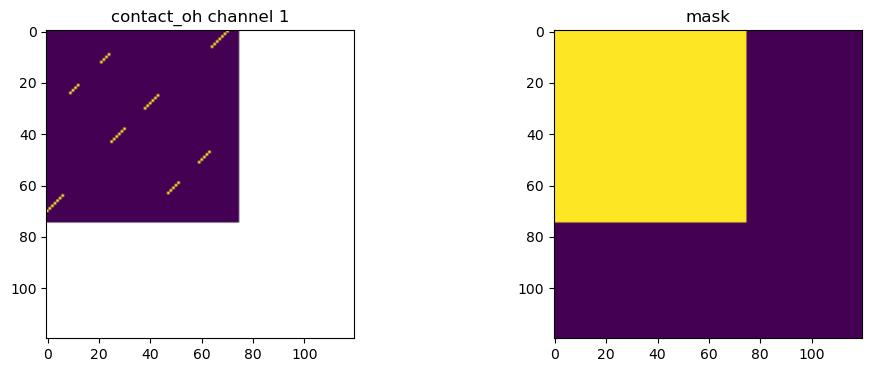

In [63]:
x0_real = batch['contact_oh'][idx:idx + 1].float()
mask_real = batch['mask'][idx:idx + 1]
cond = batch['conditioning'][idx:idx + 1].float()
contact_real = x0_real[0]
mask2d = mask_real[0, 0]

print('valid pixel:', contact_real[:, 0, 0])
print('evaluation at seq_len:', seq_len)
print('padded pixel:', contact_real[:, seq_len, seq_len])
print('mask padded pixel:', mask2d[seq_len, seq_len])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(contact_real[1])
axes[0].set_title('contact_oh channel 1')
axes[1].imshow(mask2d)
axes[1].set_title('mask')
plt.show()

## 4. `q_pred` mantiene `NaN` fuera de mascara


In [64]:
# weights_path = "/home/gkulemeyer/Documents/Repos/RNADiffusion/logs/test_model_25ts.pt"
# weights = tr.load(weights_path, map_location='cpu')
# weights.keys()

q valid pixel: tensor([    1.0000,     0.0000])
q padded pixel: tensor([nan, nan])


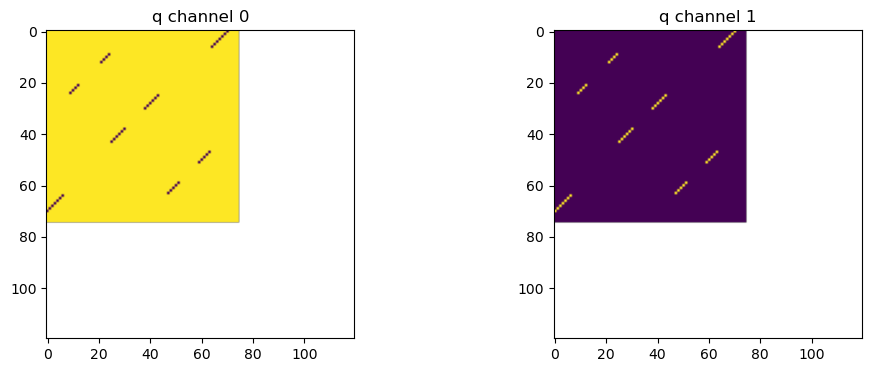

In [65]:
model = DiffusionModel(
    num_classes=2,
    time_steps=25,
    model=SimpleUNet,
    in_channels=18,
    out_channels=2,
    base_dim=64,
).eval()
# model.load_state_dict(tr.load(weights_path, map_location='cpu'))

time0 = tr.tensor([0])
q = model.q_pred(x0_real, time0)

print('q valid pixel:', q[0, :, 0, 0])
print('q padded pixel:', q[0, :, seq_len, seq_len])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(q[0, 0])
axes[0].set_title('q channel 0')
axes[1].imshow(q[0, 1])
axes[1].set_title('q channel 1')
plt.show()

## 5. Saneo localizado justo antes del backbone


In [66]:
q_sum = q.nansum(dim=1)

print('sum valid pixel:', q_sum[0, 0, 0])
print('sum padded pixel:', q_sum[0, seq_len, seq_len])
print('q finite in valid region:', tr.isfinite(q[:, :, :seq_len, :seq_len]).all())
print('q finite in padding:', tr.isfinite(q[0, :, seq_len, seq_len]))


sum valid pixel: tensor(1.)
sum padded pixel: tensor(0.)
q finite in valid region: tensor(True)
q finite in padding: tensor([False, False])


## 6. Forward diffusion + loss solo en pixeles validos


In [67]:
time = tr.tensor([model.time_steps // 2])
q = model.q_pred(x0_real, time)
print(f"q shape: {q.shape}")
xt = model.q_sample(x0_real, time, mask=mask_real) 
print(f"xt shape: {xt.shape}")
raw_post = model.q_pred(x0_real, tr.clamp(time - 1, min=0)) * model.q_step(xt, time) # norm 
print(f"raw_post shape: {raw_post.shape}")
post = model.q_posterior(x0_real, xt, time)
print(f"post shape: {post.shape}")
xt_backbone, cond_backbone = model._prepare_backbone_inputs(xt, cond, mask=mask_real)
pred_x0 = model.predict_start(xt, time, cond, mask=mask_real)
vlb = model.compute_vlb(x0_real, xt, time, cond, mask=mask_real)
print(xt_backbone.shape, cond_backbone.shape, pred_x0.shape)
print('xt padded before backbone:', xt[0, seq_len, seq_len])
print('xt padded at backbone:', xt_backbone[0, :, seq_len, seq_len])
print('conditioning padded before backbone:', cond[0, :4, seq_len, seq_len])
print('conditioning padded at backbone:', cond_backbone[0, :4, seq_len, seq_len])
print('predict_start padded:', pred_x0[0, :, seq_len, seq_len], 'sum =', pred_x0[0, :, seq_len, seq_len].sum())
print('vlb finite:', tr.isfinite(vlb), 'value =', vlb)


q shape: torch.Size([1, 2, 120, 120])
xt shape: torch.Size([1, 120, 120])


IndexError: The shape of the mask [1, 120, 120] at index 1 does not match the shape of the indexed tensor [1, 2, 120, 120] at index 1

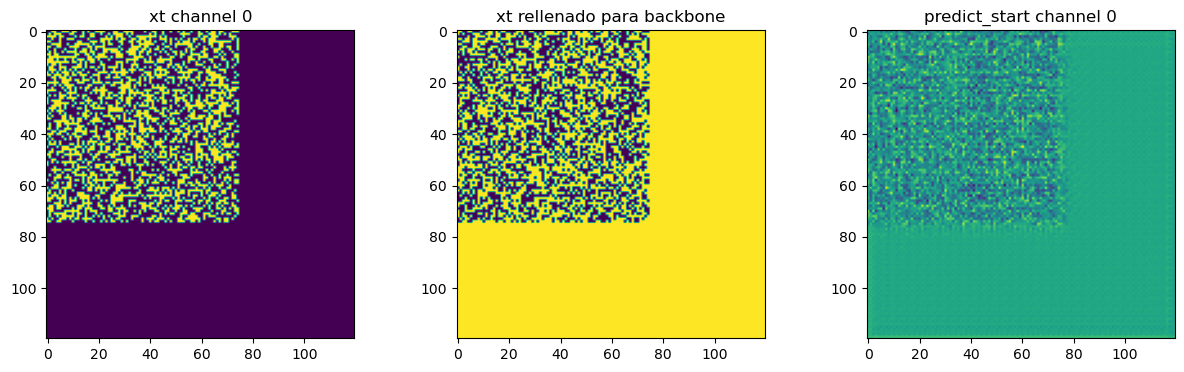

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(xt[0])
axes[0].set_title('xt channel 0')
axes[1].imshow(xt_backbone[0, 0])
axes[1].set_title('xt rellenado para backbone')
axes[2].imshow(pred_x0[0, 1].detach().numpy())
axes[2].set_title('predict_start channel 0')
plt.show()


In [ ]:
times = [tr.tensor([t]) for t in range(0, model.time_steps, 5)]
qt = [model.q_pred(x0_real, time_t) for time_t in times]
xt_t = [model.q_sample(x0_real, time_t, mask=mask_real) for time_t in times]
xt_t_backbone = []
for i, (xt, time_t) in enumerate(zip(xt_t, times)):
    xt_backbone, _ = model._prepare_backbone_inputs(xt, cond, mask=mask_real)
    xt_t_backbone.append(xt_backbone)
pred_t = [model.predict_start(xt_t, time_t, cond, mask=mask_real) for xt_t, time_t in zip(xt_t, times)]

# plot (4, times) and show q, xt and xt_backbone, pred
fig, axes = plt.subplots(4, len(times), figsize=(4 * len(times), 10))
for i, time_t in enumerate(times):
    print(f" shapes: q: {qt[i].shape}, xt: {xt_t[i].shape}, xt_backbone: {xt_t_backbone[i].shape}, pred: {pred_t[i].shape}")
    axes[0,i].imshow(qt[i][0, 0], vmin=0, vmax=1)
    axes[0, i].set_title(f'q t={time_t.item()}')
    axes[1, i].imshow(xt_t[i][0], vmin=0, vmax=1)
    axes[1, i].set_title(f'xt t={time_t.item()}')
    axes[2, i].imshow(xt_t_backbone[i][0, 0], vmin=0, vmax=1)
    axes[2, i].set_title(f'xt backbone  t={time_t.item()}')
    axes[3, i].imshow(pred_t[i][0, 0].detach().numpy(), vmin=0, vmax=1)
    axes[3, i].set_title(f'pred_x0 t={time_t.item()}')
for ax in axes.flatten():
    ax.axis('off')
fig.tight_layout()
plt.show()

RuntimeError: Index put requires the source and destination dtypes match, got Float for the destination and Long for the source.

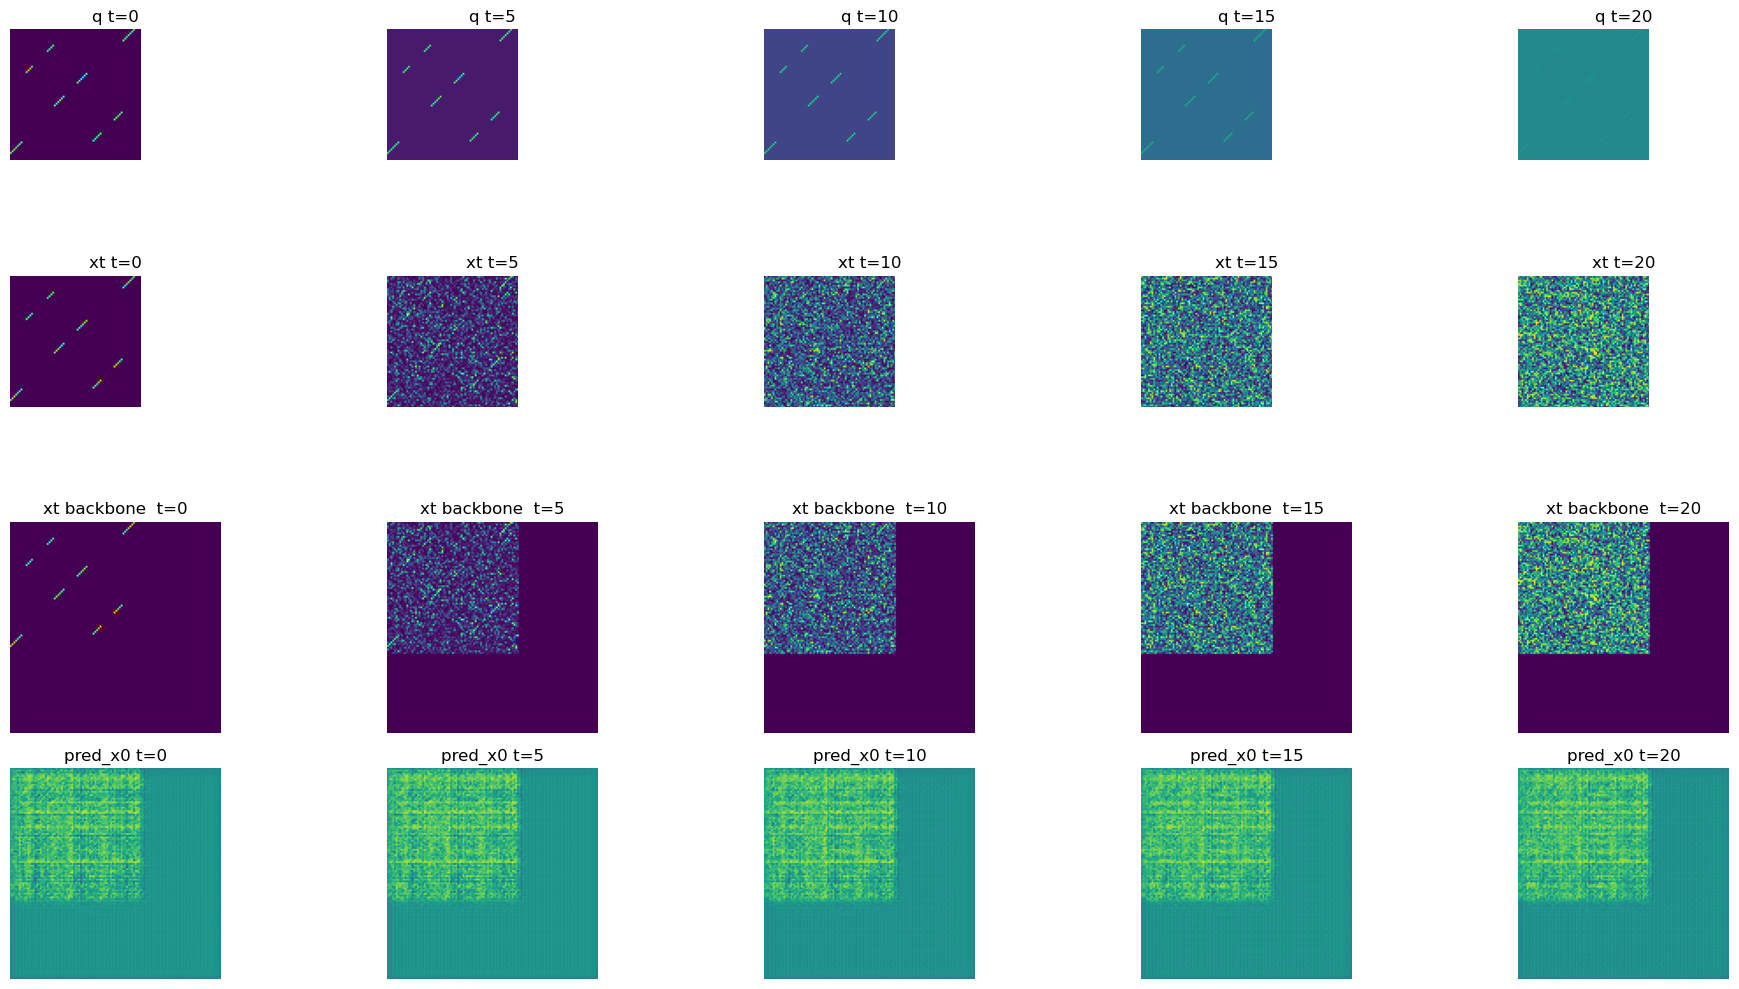

In [ ]:
times = [tr.tensor([t]) for t in range(0, model.time_steps, 5)]
# plot (4, times) and show q, xt and xt_backbone, pred
fig, axes = plt.subplots(4, len(times), figsize=(4 * len(times), 10))
for i, time_t in enumerate(times):
    qt = model.q_pred(x0_real, time_t)
    xt_t = model.q_sample(x0_real, time_t, gumbel=True)
    xt_t_backbone, _ = model._prepare_backbone_inputs(xt_t, cond, mask_real)
    pred_t = model.predict_start(xt_t, time_t, cond, mask=mask_real) 
    axes[0 ,i].imshow(qt[0, 1], vmin=0, vmax=1)
    axes[0, i].set_title(f'q t={time_t.item()}')
    axes[1, i].imshow(xt_t[0, 1], vmin=0, vmax=1)
    axes[1, i].set_title(f'xt t={time_t.item()}')
    axes[2, i].imshow(xt_t_backbone[0, 1], vmin=0, vmax=1)
    axes[2, i].set_title(f'xt backbone  t={time_t.item()}')
    axes[3, i].imshow(pred_t[0, 1].detach().numpy(), vmin=0, vmax=1)
    axes[3, i].set_title(f'pred_x0 t={time_t.item()}')
for ax in axes.flatten():
    ax.axis('off')
fig.tight_layout()
plt.show()

In [ ]:
print('contact padded:', x0_real[0, :, seq_len, seq_len])
print('conditioning padded:', cond[0, :4, seq_len, seq_len])
print('mask padded:', mask_real[0, 0, seq_len, seq_len])


contact padded: tensor([nan, nan])
conditioning padded: tensor([nan, nan, nan, nan])
mask padded: tensor(False)


In [ ]:
true_posterior = model.q_posterior(x0_real, xt, time)
pred_posterior = model.q_posterior(pred_x0, xt, time)
eps = 1e-8
true_posterior = tr.clamp(true_posterior, min=eps, max=1.0)
pred_posterior = tr.clamp(pred_posterior, min=eps, max=1.0)
kl = true_posterior * (tr.log(true_posterior) - tr.log(pred_posterior))
kl_pixelwise = tr.sum(kl, dim=1)
print('kl_pixelwise shape:', kl_pixelwise)
kl_pixelwise_nan = tr.nansum(kl, dim=1)
print('kl_pixelwise nan shape:', kl_pixelwise_nan)

print('raw padded kl:', kl_pixelwise[0, seq_len, seq_len])
print('masked with multiplication:', (kl_pixelwise * mask_real.squeeze(1))[0, seq_len, seq_len])
print('valid mean with boolean indexing:', kl_pixelwise[mask_real.squeeze(1)].mean())


kl_pixelwise shape: tensor([[[0.1169, 0.0621, 0.0594,  ...,    nan,    nan,    nan],
         [0.1633, 0.2535, 0.1237,  ...,    nan,    nan,    nan],
         [0.1971, 0.2240, 0.2284,  ...,    nan,    nan,    nan],
         ...,
         [   nan,    nan,    nan,  ...,    nan,    nan,    nan],
         [   nan,    nan,    nan,  ...,    nan,    nan,    nan],
         [   nan,    nan,    nan,  ...,    nan,    nan,    nan]]],
       grad_fn=<SumBackward1>)
kl_pixelwise nan shape: tensor([[[0.1169, 0.0621, 0.0594,  ..., 0.0000, 0.0000, 0.0000],
         [0.1633, 0.2535, 0.1237,  ..., 0.0000, 0.0000, 0.0000],
         [0.1971, 0.2240, 0.2284,  ..., 0.0000, 0.0000, 0.0000],
         ...,
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]]],
       grad_fn=<NansumBackward0>)
raw padded kl: tensor(nan, grad_fn=<SelectBackward0>)
masked with multiplicatio

In [ ]:
print('Regla de implementacion:')
print('- Batch padded con NaN en contact_oh y conditioning')
print('- Backbone recibe conditioning=0 y xt/contact=[1,0] fuera de mask')
print('- Loss y sampling solo consideran pixeles validos')


Regla de implementacion:
- Batch padded con NaN en contact_oh y conditioning
- Backbone recibe conditioning=0 y xt/contact=[1,0] fuera de mask
- Loss y sampling solo consideran pixeles validos


## 7. Reverse sampling con mascara


In [ ]:
p_step = model.p_sample(tr.argmax(xt, dim=1), time, cond, mask=mask_real)

print('p_sample valid:', p_step[0, 0, 0])
print('p_sample padded:', p_step[0, seq_len, seq_len])


p_sample valid: tensor(0)
p_sample padded: tensor(0)


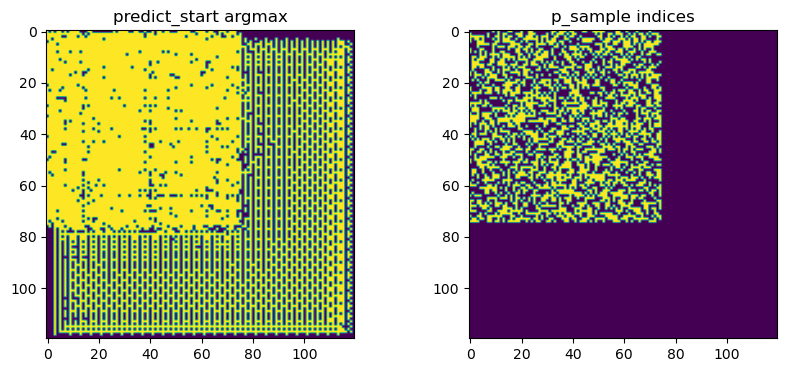

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(tr.argmax(pred_x0[0], dim=0))
axes[0].set_title('predict_start argmax')
axes[1].imshow(p_step[0])
axes[1].set_title('p_sample indices')
plt.show()


## 8. Sampling completo


In [ ]:
pred_x0 = model.predict_start(xt, time, cond, mask=mask_real)
sample_full = model.sample(cond, mask=mask_real)

print('predict_start padded:', pred_x0[0, :, seq_len, seq_len], 'sum =', pred_x0[0, :, seq_len, seq_len].sum())
print('_sample padded:', sample_full[0, seq_len, seq_len])


predict_start padded: tensor([0.4606, 0.5394], grad_fn=<SelectBackward0>) sum = tensor(1., grad_fn=<SumBackward0>)
_sample padded: tensor(0)


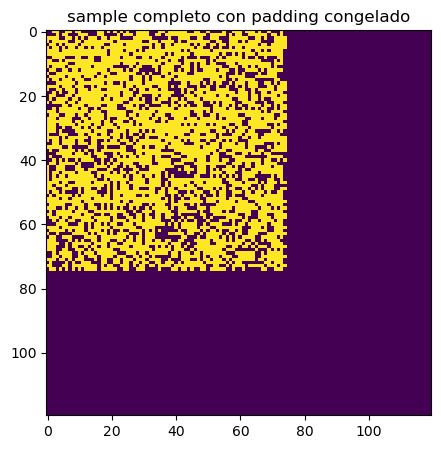

In [ ]:
tr.manual_seed(0)
sample_full = model.sample(cond, mask=mask_real)

plt.figure(figsize=(6, 5))
plt.imshow(sample_full[0])
plt.title('sample completo con padding congelado')
plt.show()
